In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
with open("example.json", "r") as f:
    data = json.load(f)

In [3]:
df = pd.read_csv('40_small.csv')

In [4]:
df

,Formula,E1,E2,E3,E4,E5,E6,E7,E8,E9,...,E31,E32,E33,E34,E35,E36,E37,E38,E39,E40
0,CrCuO2,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,59892.231250,...,1.081583e+06,1227100.0,1.344108e+06,1443194.750,1.486846e+06,1428422.500,1.316417e+06,1.204693e+06,1.220112e+06,1171280.00
1,Cr3CuO8,0.0,0.000000,30859.862500,85562.240,119523.6250,141757.750,168197.050,210310.600,235846.550000,...,1.359480e+06,1423598.0,1.432965e+06,1437496.500,1.363450e+06,1364722.000,1.267831e+06,1.174754e+06,1.075169e+06,943328.00
2,CrCuO4,0.0,859.747513,4824.629687,25734.960,31048.1125,38355.620,38402.960,92456.305,167976.087500,...,1.362838e+06,1489568.0,1.435338e+06,1283780.250,1.244586e+06,1244165.500,1.081084e+06,9.862068e+05,8.453162e+05,771056.75
3,Li3Cr2CuO6,0.0,0.000000,0.000000,0.000,7633.0875,57731.415,143464.125,217480.600,253357.525000,...,1.141043e+06,1176918.0,1.195756e+06,1204154.500,1.165874e+06,1170425.000,1.176721e+06,1.141456e+06,1.132196e+06,1108820.00
4,NCl3,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,19947.240625,...,1.399801e+05,226223.0,7.358476e+05,1297148.750,8.587992e+05,474191.375,4.085255e+05,4.385053e+05,5.218982e+05,1005965.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaTl3(SO3)2,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,0.000000,...,1.077122e+06,1191960.0,1.094578e+06,980973.375,8.997337e+05,941166.000,9.158847e+05,9.273319e+05,9.273660e+05,847677.00
96,K2Cd(NO2)4,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,0.000000,...,2.875168e+05,343715.6,4.148941e+05,422175.200,5.775640e+05,780219.600,7.469680e+05,6.162132e+05,5.802944e+05,558624.00
97,Li3Mn2SbO6,0.0,441.668750,1888.783000,6111.757,16415.7750,24463.555,24370.880,25551.540,31318.395000,...,1.081268e+06,1231234.0,1.288470e+06,1309920.000,1.313814e+06,1298071.000,1.310110e+06,1.337440e+06,1.344303e+06,1284260.00
98,C3N4,0.0,0.000000,0.000000,995.707,1735.5150,2915.090,4853.175,8665.280,16051.850000,...,2.124495e+05,207119.0,1.863810e+05,202427.000,2.217385e+05,277593.000,3.617785e+05,4.279700e+05,5.278475e+05,573213.00


In [5]:
energies = np.linspace(0,5,41)

In [20]:
alphas = df.loc[df['Formula']=='CrCuO2'].iloc[0,1:].tolist()

Text(0, 0.5, '$\\alpha$ / cm$^{-1}$')

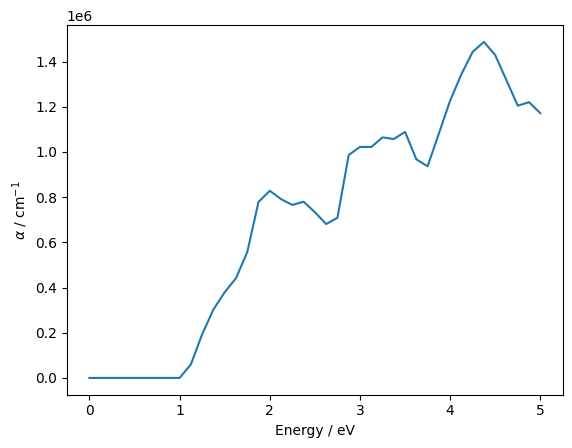

In [25]:
plt.plot(energies,[0]+alphas)
plt.xlabel('Energy / eV')
plt.ylabel(r'$\alpha$ / cm$^{-1}$')

In [27]:
from matminer.featurizers.conversions import StrToComposition
from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty

/home/matthew/miniforge3/envs/FGW/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
str_comp = StrToComposition(target_col_id='composition')
data_comp = str_comp.featurize_dataframe(df, col_id='Formula')
featurizer = ElementProperty.from_preset('magpie')
featurized_data = featurizer.featurize_dataframe(data_comp, col_id='composition')

ElementProperty: 100%|██████████| 100/100 [00:00<00:00, 494.95it/s]


In [30]:
featurized_data

,Formula,E1,E2,E3,E4,E5,E6,E7,E8,E9,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,CrCuO2,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,59892.231250,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,119.500000,107.500000,12.0
1,Cr3CuO8,0.0,0.000000,30859.862500,85562.240,119523.6250,141757.750,168197.050,210310.600,235846.550000,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,84.000000,96.000000,12.0
2,CrCuO4,0.0,859.747513,4824.629687,25734.960,31048.1125,38355.620,38402.960,92456.305,167976.087500,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,83.666667,95.555556,12.0
3,Li3Cr2CuO6,0.0,0.000000,0.000000,0.000,7633.0875,57731.415,143464.125,217480.600,253357.525000,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,120.166667,108.166667,12.0
4,NCl3,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,19947.240625,...,0.00000,0.000000,0.000000,0.0,64.0,194.0,130.0,96.500000,48.750000,64.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaTl3(SO3)2,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,0.000000,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,85.250000,78.333333,12.0
96,K2Cd(NO2)4,0.0,0.000000,0.000000,0.000,0.0000,0.000,0.000,0.000,0.000000,...,0.00000,0.000000,0.000000,0.0,12.0,229.0,217.0,101.600000,95.573333,12.0
97,Li3Mn2SbO6,0.0,441.668750,1888.783000,6111.757,16415.7750,24463.555,24370.880,25551.540,31318.395000,...,0.00031,0.000052,0.000086,0.0,12.0,229.0,217.0,113.250000,101.250000,12.0
98,C3N4,0.0,0.000000,0.000000,995.707,1735.5150,2915.090,4853.175,8665.280,16051.850000,...,0.00000,0.000000,0.000000,0.0,194.0,194.0,0.0,194.000000,0.000000,194.0
